In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

In [5]:
DATA_PATH = "../data/15-data.csv"
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["mean_entropy"])

In [6]:
features = ["Step","learning_rate","num_epoch","batch_size","buffer_size","beta","epsilon","lambd"]
X = df[features]
y = df["mean_entropy"]

In [7]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

In [8]:
model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=None
)
pipe.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



=== Top features by RF built-in importance ===
learning_rate    0.266198
beta             0.170688
epsilon          0.169316
lambd            0.163471
buffer_size      0.092705
num_epoch        0.082776
batch_size       0.049590
Step             0.005256
dtype: float64


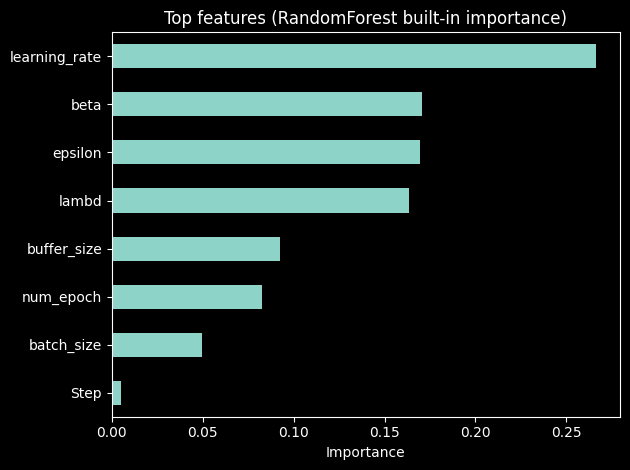

In [10]:
rf = pipe.named_steps["model"]
fi = pd.Series(rf.feature_importances_, index=numeric_features).sort_values(ascending=False)

TOP_K = 10
print("\n=== Top features by RF built-in importance ===")
print(fi.head(TOP_K))

plt.figure()
fi.head(TOP_K).sort_values().plot(kind="barh")
plt.title("Top features (RandomForest built-in importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


=== Top features by Permutation Importance ===
learning_rate    1.068899
epsilon          0.682332
batch_size       0.565420
lambd            0.463514
beta             0.328566
buffer_size      0.326495
num_epoch        0.306033
Step             0.001329
dtype: float64


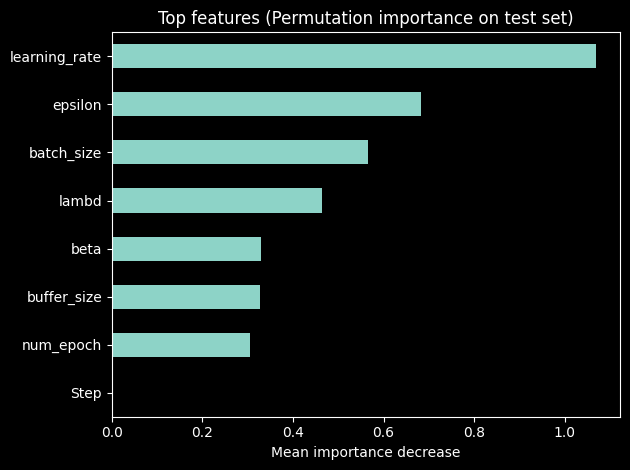

In [11]:
perm = permutation_importance(
    pipe,
    X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_imp = pd.Series(perm.importances_mean, index=numeric_features).sort_values(ascending=False)

print("\n=== Top features by Permutation Importance ===")
print(perm_imp.head(TOP_K))

plt.figure()
perm_imp.head(TOP_K).sort_values().plot(kind="barh")
plt.title("Top features (Permutation importance on test set)")
plt.xlabel("Mean importance decrease")
plt.tight_layout()
plt.show()


=== Top features by SHAP Importance ===


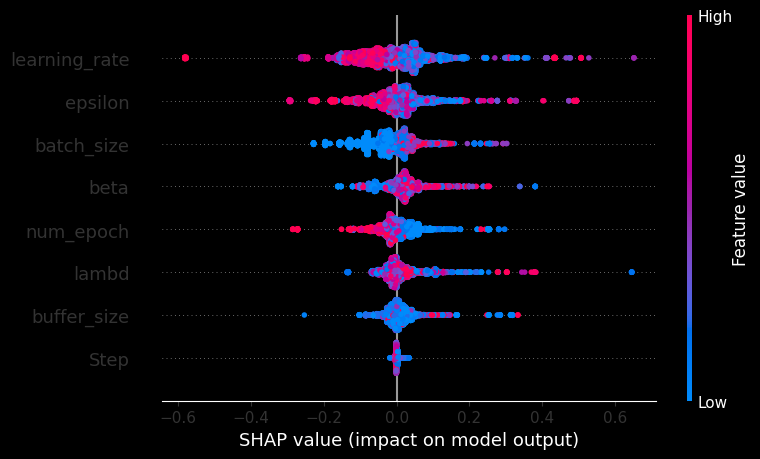

In [13]:
import shap

# Transform data for SHAP (TreeExplainer expects the same input used by the RF model)
X_test_transformed = pipe.named_steps["preprocess"].transform(X_test)

# TreeExplainer for RandomForest
explainer = shap.TreeExplainer(rf)

# For classification, shap_values can be list (per class)
shap_values = explainer.shap_values(X_test_transformed)

print("\n=== Top features by SHAP Importance ===")
plt.figure()
shap.summary_plot(shap_values, X_test_transformed, feature_names=numeric_features, show=False)

plt.tight_layout()
plt.show()